## Build a basic ChatBot with langgraph(Graph API)

In [10]:
from typing import Annotated # Annotated is used for type annotations with additional metadata
from typing_extensions import TypedDict # TypedDict is used to define a dictionary with specific keys and value types

from langgraph.graph import StateGraph, START, END # StateGraph is a class for managing a graph of states, START and END are constants representing the starting and ending states
from langgraph.graph.message import add_messages # add_messages is a function (reducers) to add messages to the graph

In [11]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State) # Create a new StateGraph with the defined State type

In [5]:
graph_builder

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama3-8b-8192")

In [20]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1102a9950>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1102aa5d0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [3]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1111bd090>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1111bda90>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [27]:
## node functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [ ]:
graph_builder = StateGraph(State) # Create a new StateGraph with the defined State type

## Addning node
graph_builder.add_node("llmchatbot", chatbot) # Add a node to the graph with the name "llmchatbot" and the functionality defined in the chatbot function

## Adding Edge
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

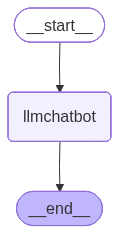

In [29]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [30]:
response=graph.invoke({"messages":"Hi"})

In [31]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='d7ce5556-d954-46ae-a53f-ca8979884791'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 36, 'total_tokens': 60, 'completion_time': 0.062695601, 'completion_tokens_details': None, 'prompt_time': 0.000995471, 'prompt_tokens_details': None, 'queue_time': 0.054321179, 'total_time': 0.063691072}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8b76-9c1b-7471-ac08-53fdde70a692-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 24, 'total_tokens': 60})]}

In [32]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with, or would you like to chat?"

In [ ]:
# graph.stream() returns an iterator of events that occur as the graph processes the input. Each event is a dictionary containing information about the current state of the graph, including any messages that have been generated.

for event in graph.stream({"messages":"Hello, how are you?"}): 
    print(event)


{'llmchatbot': {'messages': [AIMessage(content="Hello, I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 41, 'total_tokens': 99, 'completion_time': 0.128349035, 'completion_tokens_details': None, 'prompt_time': 0.002119648, 'prompt_tokens_details': None, 'queue_time': 0.162235041, 'total_time': 0.130468683}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8b83-2910-7061-be98-fda1bfc9a28e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 58, 'total_tokens': 99})]}}


In [ ]:
for event in graph.stream({"messages":"Hello, how are you?"}): 
    for value in event.values():
        print(value)

{'messages': [AIMessage(content="Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 41, 'total_tokens': 89, 'completion_time': 0.098287349, 'completion_tokens_details': None, 'prompt_time': 0.002230732, 'prompt_tokens_details': None, 'queue_time': 0.051199377, 'total_time': 0.100518081}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8b84-e6c8-7143-8b5f-943ca62fbefe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 48, 'total_tokens': 89})]}


In [35]:
for event in graph.stream({"messages":"Hello, how are you?"}): 
    for value in event.values():
        print(value["messages"][-1].content) # only ai message content will be displayed

Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or topics you'd like to discuss. How can I help you today?


## ChatBot with tools

In [4]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

tool.invoke("What is langchain?")

{'query': 'What is langchain?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.coursera.org/articles/what-is-langchain',
   'title': 'What Is LangChain? | Coursera',
   'content': 'Expand your knowledge of LangChain, discover its main applications, and explore the potential advantages and disadvantages of utilizing the tool. LangChain is a framework for developing applications driven by large language models (LLMs). It’s available in the Python and JavaScript libraries and can aid in the development of applications such as chatbots and virtual agents. According to IBM, “LangChain enjoyed a meteoric rise to prominence: as of June 2023, it was the single fastest-growing open source project on GitHub. Coinciding with the momentous launch of OpenAI’s ChatGPT the following month, LangChain has played a significant role in making generative AI more accessible to enthusiasts in the wake of its widespread popularity” [1]. Explore LangChain’s fra

In [5]:
## custom function

def multiply(a: int, b: int) -> int:
    """multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: the product of a and b
    """
    return a * b

In [7]:
tools = [tool, multiply]

llm_with_tools = llm.bind_tools(tools)

llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1111bd090>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1111bda90>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-tim

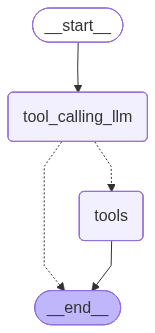

In [14]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools", END)

# compile the graph
graph = builder.compile()


from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [15]:
response=graph.invoke({"messages":"What is the recent ai news"})
response

{'messages': [HumanMessage(content='What is the recent ai news', additional_kwargs={}, response_metadata={}, id='604a52b6-2c08-4927-b50b-2124397ca439'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4af7yfk28', 'function': {'arguments': '{"query":"recent ai news","search_depth":"basic","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1751, 'total_tokens': 1789, 'completion_time': 0.11291619, 'completion_tokens_details': None, 'prompt_time': 0.09865302, 'prompt_tokens_details': None, 'queue_time': 0.051075709, 'total_time': 0.21156921}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e90ab-d8b8-72d3-998f-d210536f2cff-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent ai news', 'search_dept

In [16]:
response["messages"][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tipranks.com/news/private-companies/ubeya-highlights-ai-driven-workforce-analytics-capability", "title": "Ubeya Highlights AI-Driven Workforce Analytics Capability - TipRanks", "score": 0.6158511, "published_date": "Wed, 03 Jun 2026 12:04:41 GMT", "content": "# Ubeya Highlights AI-Driven Workforce Analytics Capability. According to a recent LinkedIn post from Ubeya, the company is highlighting a new AI-driven feature called Ubeya AI Insights aimed at simplifying workforce data analysis. * Unlock trusted, data-backed investing tools with TipRanks Premium, from analyst ratings and forecasts to breaking news and portfolio analysis. * Discover high-conviction stock picks and new investing opportunities with the TipRanks Smart Investor Newsletter. The post suggests that AI Insights is intended to deliver instant answers and reveal operational trends without the need to ma

In [17]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (4af7yfk28)
 Call ID: 4af7yfk28
  Args:
    query: recent ai news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tipranks.com/news/private-companies/ubeya-highlights-ai-driven-workforce-analytics-capability", "title": "Ubeya Highlights AI-Driven Workforce Analytics Capability - TipRanks", "score": 0.6158511, "published_date": "Wed, 03 Jun 2026 12:04:41 GMT", "content": "# Ubeya Highlights AI-Driven Workforce Analytics Capability. According to a recent LinkedIn post from Ubeya, the company is highlighting a new AI-driven feature called Ubeya 

In [18]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (03t6vghs0)
 Call ID: 03t6vghs0
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [19]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (s8s1mary6)
 Call ID: s8s1mary6
  Args:
    query: recent ai news
    search_depth: basic
    time_range: day
  multiply (k0tftz4wc)
 Call ID: k0tftz4wc
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://aibusiness.com/responsible-ai/ai-ethics", "title": "AI Ethics recent news", "content": "Explore the latest news and expert commentary on AI Ethics, brought to you by the editors of AI Business.", "score": 0.6578248, "raw_content": null}, {"url": "https://www.facebook.com/techinsider/posts/sam-altman-said-ai-budgeting-has-recently-become-a-huge-issue-for-so

## ReAct agent architecture

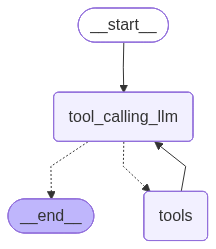

In [20]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

# compile the graph
graph = builder.compile()


from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print() ## now the graph will loop back to the llm after executing the tool, allowing for multiple tool calls in a single conversation and a goof to the point answering

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (dn7pb2wdf)
 Call ID: dn7pb2wdf
  Args:
    query: recent AI news
    search_depth: basic
    time_range: day
    topic: news
  multiply (5sazhzgek)
 Call ID: 5sazhzgek
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://michaelparekh.substack.com/p/ai-kudos-to-3-ai-arbiters-on-against", "title": "AI: Kudos to 3 AI Arbiters on ‘Against the Grain’ Calls. ARD #91 - AI: Reset to Zero", "score": 0.6337056, "published_date": "Fri, 05 Jun 2026 16:46:24 GMT", "content": "Today’s theme: **kudos to three AI arbiters** — the **S&P 500**, **SemiAnalysis**, and **The A

## Adding memory in Agentic graph

In [22]:
response=graph.invoke({"messages":"Hello my name is Ayush"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Ayush
================================== Ai Message ==================================

Hello Ayush, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [23]:
response=graph.invoke({"messages":"What is my name?"})
for m in response['messages']:
    m.pretty_print() # will not work as the graph currently does not have memory of past conversations, it only processes the current input and does not retain any information from previous interactions

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


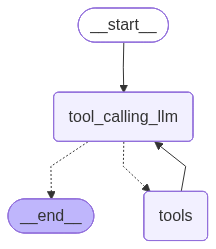

In [33]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

# compile the graph
graph = builder.compile(checkpointer=memory)


from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [34]:
config = {"configurable": {"thread_id": 1}}

response = graph.invoke({"messages":"Hello my name is Ayush"}, config=config)

response

{'messages': [HumanMessage(content='Hello my name is Ayush', additional_kwargs={}, response_metadata={}, id='3deed312-7914-45ff-a262-8f3eb4a4cd85'),
  AIMessage(content="Hello Ayush! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1751, 'total_tokens': 1778, 'completion_time': 0.079428888, 'completion_tokens_details': None, 'prompt_time': 0.167214751, 'prompt_tokens_details': None, 'queue_time': 0.163519866, 'total_time': 0.246643639}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9cfb-11b3-7f20-9d63-fb09c3ac5f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1751, 'output_tokens': 27, 'total_tokens': 1778})]}

In [35]:
response["messages"][-1].content

"Hello Ayush! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [36]:
response = graph.invoke({"messages":"What is my name?"}, config=config)

response

{'messages': [HumanMessage(content='Hello my name is Ayush', additional_kwargs={}, response_metadata={}, id='3deed312-7914-45ff-a262-8f3eb4a4cd85'),
  AIMessage(content="Hello Ayush! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1751, 'total_tokens': 1778, 'completion_time': 0.079428888, 'completion_tokens_details': None, 'prompt_time': 0.167214751, 'prompt_tokens_details': None, 'queue_time': 0.163519866, 'total_time': 0.246643639}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9cfb-11b3-7f20-9d63-fb09c3ac5f1b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1751, 'output_tokens': 27, 'total_tokens': 1778}),
  HumanMessage(content='What is my name?', additional_kwargs={}, 

In [37]:
response["messages"][-1].content

'Your name is Ayush.'

## streaming

In [64]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [65]:
def superbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

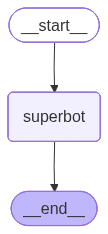

In [66]:
graph = StateGraph(State)

graph.add_node("superbot", superbot)

graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

from IPython.display import Image, display

try:
    display(Image(graph_builder.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [45]:
## invocation

config = {"configurable": {"thread_id": 1}}

graph_builder.invoke({"messages":"Hello my name is Ayush and I love cricket"}, config=config)

{'messages': [HumanMessage(content='Hello my name is Ayush and I love cricket', additional_kwargs={}, response_metadata={}, id='c2cf8215-77a8-49c5-9bde-3f79e49cf4f2'),
  AIMessage(content="Hello Ayush, nice to meet you. Cricket is an amazing sport, and I'm sure you must be excited about the various tournaments and leagues happening around the world. Which team or player is your favorite? Are you a fan of Test cricket, ODIs, or T20s? Let's chat about cricket.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 45, 'total_tokens': 110, 'completion_time': 0.225108195, 'completion_tokens_details': None, 'prompt_time': 0.003453762, 'prompt_tokens_details': None, 'queue_time': 0.163392546, 'total_time': 0.228561957}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9d18-ac84-72a2-9ed9-5d9f99c57c73-0'

### Streaming

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- values : This streams the full state of the graph after each node is called.
- updates : This streams updates to the state of the graph after each node is called.

In [54]:
# create a thread

config = {"configurable": {"thread_id": 3}}

for chunk in graph_builder.stream({"messages":"Hello my name is Ayush and I love cricket"}, config=config, stream_mode="updates"): 
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Nice to meet you, Ayush. Cricket is an exciting sport, and it's great that you're passionate about it. Are you a fan of a particular team or player? Do you have a favorite format, like Test cricket, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 45, 'total_tokens': 101, 'completion_time': 0.197099739, 'completion_tokens_details': None, 'prompt_time': 0.002205213, 'prompt_tokens_details': None, 'queue_time': 0.050376247, 'total_time': 0.199304952}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9d20-ed66-7711-91b1-909c46daf6f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 56, 'total_tokens': 101})]}}


In [55]:
for chunk in graph_builder.stream({"messages":"Hello my name is Ayush and I love cricket"}, config=config, stream_mode="values"): 
    print(chunk)

{'messages': [HumanMessage(content='Hello my name is Ayush and I love cricket', additional_kwargs={}, response_metadata={}, id='ff26ea24-2045-4d86-9d5b-f98ff1bc17f2'), AIMessage(content="Nice to meet you, Ayush. Cricket is an exciting sport, and it's great that you're passionate about it. Are you a fan of a particular team or player? Do you have a favorite format, like Test cricket, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 45, 'total_tokens': 101, 'completion_time': 0.197099739, 'completion_tokens_details': None, 'prompt_time': 0.002205213, 'prompt_tokens_details': None, 'queue_time': 0.050376247, 'total_time': 0.199304952}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9d20-ed66-7711-91b1-909c46daf6f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

In [67]:
# create a thread

config = {"configurable": {"thread_id": 4}}

for chunk in graph_builder.stream({"messages":"Hello my name is Ayush and I love cricket"}, config=config, stream_mode="updates"): 
    print(chunk)

{'superbot': {'messages': [AIMessage(content="Hello Ayush, nice to meet you. Cricket is an amazing sport, and it's great to hear that you're a fan. Which team or player is your favorite? Are you more into international cricket, IPL, or do you enjoy playing the game yourself?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 45, 'total_tokens': 99, 'completion_time': 0.195327147, 'completion_tokens_details': None, 'prompt_time': 0.002103598, 'prompt_tokens_details': None, 'queue_time': 0.175403679, 'total_time': 0.197430745}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9d23-fc1d-7742-904c-0d9ab3235aa5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 54, 'total_tokens': 99})]}}


In [68]:

for chunk in graph_builder.stream({"messages":"I also like football"}, config=config, stream_mode="values"): 
    print(chunk)

{'messages': [HumanMessage(content='Hello my name is Ayush and I love cricket', additional_kwargs={}, response_metadata={}, id='a630e33a-a6fb-46c3-819e-92e5bf13d979'), AIMessage(content="Hello Ayush, nice to meet you. Cricket is an amazing sport, and it's great to hear that you're a fan. Which team or player is your favorite? Are you more into international cricket, IPL, or do you enjoy playing the game yourself?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 45, 'total_tokens': 99, 'completion_time': 0.195327147, 'completion_tokens_details': None, 'prompt_time': 0.002103598, 'prompt_tokens_details': None, 'queue_time': 0.175403679, 'total_time': 0.197430745}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9d23-fc1d-7742-904c-0d9ab3235aa5-0', tool_calls=[], invalid_tool_calls=[], usage_m

In [69]:
response = graph_builder.invoke({"messages":"What is my name? and what sports do i like"}, config=config)

response["messages"][-1].content

'Your name is Ayush, and you like two sports: \n\n1. Cricket\n2. Football'

In [70]:
config = {"configurable": {"thread_id": "6"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e9d27-5845-7d02-b823-b10661315871', 'metadata': {'thread_id': '6', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='f7e97d03-3056-4913-9f71-0c8d8044cbc1')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019e9d27-5891-7003-a0c0-d5803eab5d59', 'metadata': {'thread_id': '6', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:ba94989a-41f6-7061-1108-7b5c3267c56e'}, 'parent_ids': ['019e9d27-5845-7d02-b823-b10661315871']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':

## Human in the Loop